In [28]:
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from ipywidgets import interact, IntSlider

from numpy.polynomial.legendre import legval

from scipy.special import eval_legendre,legendre,factorial
from scipy.optimize import curve_fit, least_squares, differential_evolution

# Import des données

In [103]:
# Tableau : He-HCN
He = np.genfromtxt("/content/drive/MyDrive/Master/Stage/IPR/He-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

params_He = np.array([-1.69637,   -0.18540,  -0.19384,   0.01302,  0.00719, 0.02571, # b
                      -19454.791, -23297.750,-9250.9937,-45021.967,                  # c
                       11.90598,   1.33541,   2.23321,   0.31214,  0.06321,-0.13334, # d
                       0.12724,   -0.36813,  -0.18070,   0.00010,  0.24256,-0.00422, # g0
                       0.05486,    0.08842,   0.06785,  -0.01495, -0.11374, 0.02042, # g1
                      -0.01311,    0.00038,  -0.00099,   0.00252,  0.01929,-0.00554, # g2
                       0.00053,   -0.00076,  -0.00059,   0.00002, -0.00112, 0.00036])# g3
arr = np.array(
    [
        [-1.69637, -0.18540, -0.19384, 0.01302, 0.00719, 0.02571],
        [11.90598, 1.33541, 2.23321, 0.31214, 0.06321, -0.13334],
        [0.12724, -0.36813, -0.18070, 0.00010, 0.24256, -0.00422],
        [0.05486, 0.08842, 0.06785, -0.01495, -0.11374, 0.02042],
        [-0.01311, 0.00038, -0.00099, 0.00252, 0.01929, -0.00554],
        [0.00053, -0.00076, -0.00059, 0.00002, -0.00112, 0.00036],
    ]
)



array([-1.69637, -0.1854 , -0.19384,  0.01302,  0.00719,  0.02571])

In [84]:
# Tableau : Ne-HCN
Ne = np.genfromtxt("/content/drive/MyDrive/Master/Stage/IPR/Ne-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

params_Ne = np.array([-1.39799,  -0.06304,  -0.10472,  -0.10103,  -0.04239,  0.00674,  # b
                      -33692.705,-209959.32,-16394.597,-107262.52,                     # c
                       13.60561,  0.87434,   2.39464,   0.60195,   0.31713,  0.05930,  # d
                       0.10500,  -0.06621,  -0.05328,   0.01479,   0.00609, -0.00197,  # g0
                      -0.03368,   0.02788,   0.02191,  -0.00483,  -0.00308,  0.00011,  # g1
                       0.00374,  -0.00401,  -0.00298,   0.00070,   0.00054,  0.00004,  # g2
                      -0.000154,  0.000203,  0.000141, -0.000046, -0.000033,-0.000002])# g3

In [77]:
# Tableau : Ar-HCN
Ar = np.genfromtxt("/content/drive/MyDrive/Master/Stage/IPR/Ar-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

params_Ar = np.array([-1.48547,  -0.05926,  0.07533,   -0.12892,  -0.04978, 0.00004, # b
                      -134348.77,-281277.47,-57041.638,-116961.41,                   # c
                       14.23209,  0.99248,  0.88287,    0.70551,   0.38213, 0.06818, # d
                       0.06053,  -0.12937,  0.07849,   -0.05992,   0.04541, 0.03519, # g0
                       0.00640,   0.04016, -0.02325,    0.02468,  -0.02338,-0.01536, # g1
                      -0.00277,  -0.00416,  0.00221,   -0.00239,   0.00392, 0.00207, # g2
                       0.00013,   0.00015, -0.00006,    0.00003,  -0.00021,-0.00009])# g3

In [32]:
# Tableau : Kr-HCN
Kr = np.genfromtxt("/content/drive/MyDrive/Master/Stage/IPR/Kr-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

# Implémentation des fonctions

In [33]:
def f6_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x / 720.0)))))
  return 1.0 - np.exp(-x) * y

def f7_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x * (1.0/720.0 + x / 5040.0))))))
  return 1.0 - np.exp(-x) * y

In [34]:
def V_opt(p, R, Theta):
  R = np.asarray(R, dtype=float)
  # On calcule ces valeurs car utiles plusieurs fois
  cosTh = np.cos(np.deg2rad(np.asarray(Theta, dtype=float)))

  # Paramètres
  b  = p[0:6]                            # b0, b1, b2, b3, b4, b5
  c  = p[6:10]                           # c0, c1, c2, c3
  d  = p[10:16]                          # d0, d1, d2, d3, d4, d5
  g0 = np.asarray(p[16:22], dtype=float) # g00, g01, g02, g03, g04, g05
  g1 = np.asarray(p[22:28], dtype=float) # g10, g11, g12, g13, g14, g15
  g2 = np.asarray(p[28:34], dtype=float) # g20, g21, g22, g23, g24, g25
  g3 = np.asarray(p[34:40], dtype=float) # g30, g31, g32, g33, g34, g35

  # X(theta) ------------------------------------ #
  # --------------------------------------------- #
  X_b = legval(cosTh, b)
  X_d = legval(cosTh, d)

  X_bR = X_b * R
  abs_BR = np.abs(X_bR)
  # --------------------------------------------- #

  # G(R,theta) ---------------------------------- #
  # --------------------------------------------- #
  i = np.arange(6)
  g = g0[i, None] + R * (g1[i, None] + R * (g2[i, None] + R * g3[i, None]))
  Pl = np.array([eval_legendre(l, cosTh) for l in range(6)])
  # G = np.sum(g * Pl, axis=0)
  # ------------------------------------------- #

  # Short-Range
  V_sh = np.sum(g * Pl, axis=0) * np.exp(X_d-X_bR)

  # Asymptotic
  inv_R = 1.0/R
  inv_R6 = inv_R * inv_R * inv_R * inv_R * inv_R * inv_R
  inv_R7 = inv_R6 * inv_R

  V_as = (f6_opt(abs_BR) * legval(cosTh,[c[0],0,c[2]]) * inv_R6
        + f7_opt(abs_BR) * legval(cosTh,[0,c[1],0,c[3]]) * inv_R7)

  return V_sh + V_as

In [35]:
def rsq(y, f):
  y = np.asarray(y)
  f = np.asarray(f)
  stot = np.sum((y-np.mean(y))**2)
  sres = np.sum((y-f)**2)
  return 1.0 - sres/stot


# y == valeurs tabulées

# f == f(x, y, popt)

# Fonction d'affichage

In [36]:
def plot_interactif(
    model,
    params,
    fixed_vals,
    x,
    data,
    fixed_col,
    x_col,
    y_col,
    title="Graphique interactif",
    fixed_first=True
):

    fig = go.Figure()

    for i, val in enumerate(fixed_vals):

        # ordre des variables
        if fixed_first:
            y_model = model(params, np.full_like(x, val), x)
        else:
            y_model = model(params, x, np.full_like(x, val))

        # données
        mask = np.isclose(data[fixed_col], val)

        x_data = data[x_col][mask]
        y_data = data[y_col][mask]

        order = np.argsort(x_data)

        visible = (i == 0)

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_model,
                mode='lines',
                name='Modèle',
                visible=visible
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x_data[order],
                y=y_data[order],
                mode='markers',
                name='Données',
                visible=visible
            )
        )

    steps = []

    for i, val in enumerate(fixed_vals):

        vis = [False] * (2 * len(fixed_vals))

        vis[2*i] = True
        vis[2*i+1] = True

        steps.append(
            dict(
                method="update",
                args=[
                    {"visible": vis},
                    {"title": f"{fixed_col} = {val}"}
                ],
                label=str(val)
            )
        )

    fig.update_layout(
        title=title,
        sliders=[dict(steps=steps)],
        template="plotly_white",
        width=600,
        height=400,
        uirevision=True
    )

    fig.show()

# Méthode 1 : curve_fit

In [37]:
def V_curvefit(vars, *p):
    R, Theta = vars
    return V_opt(p, R, Theta)

## He-HCN

### Calculs

In [38]:
R = np.asarray(He["R"], dtype=float)
Theta = np.asarray(He["Theta"], dtype=float)
V_table = np.asarray(He["Energy"], dtype=float)
R.shape, Theta.shape, V_table.shape

((138,), (138,), (138,))

In [96]:
#params_init_cf = 10 * np.random.rand(40) - 5
#print(params_init_cf)
params_opt_cf, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_He, maxfev=1000000,
                                      method="trf")
params_opt_cf_sigma, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_He, maxfev=1000000,
                                      method="trf", sigma=V_table)

/tmp/ipykernel_3426/2755791350.py:33: RuntimeWarning:

overflow encountered in exp



In [97]:
b  = params_opt_cf[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf[6:10]  # c0, c1, c2, c3
d  = params_opt_cf[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [-0.03528543498475957, 0.005926903885472571, 0.05705172692843469, -0.011779718475331921, 0.10034848118772498, 0.03172006148974309]
[c0,c1,c2,c3]             = [-17370.62045376319, -24021.78878360181, -8839.824003421387, -45465.73250259991]
[d0,d1,d2,d3,d4,d5]       = [-50096.99287901111, 0.8521340808437319, 2.037443948404916, 0.13268637696734423, -0.008158249706645122, -0.15270754454680885]
[g00,g01,g02,g03,g04,g05] = [-5543.380698045114, 16036.50022521256, 7871.784818078462, -5.182080252595722, -10565.254600919065, 183.3233969275642]
[g10,g11,g12,g13,g14,g15] = [-2389.346872367545, -3851.8960009384696, -2955.726022206108, 651.5423316802079, 4954.227743267999, -889.2637058302633]
[g20,g21,g22,g23,g24,g25] = [571.0272115273813, -16.502203428275916, 43.154731845476654, -109.81522719996116, -840.2290933072461, 241.28836717815503]
[g30,g31,g32,g33,g34,g35] = [-23.085223805015744, 33.10275851407692, 25.698456547394226, -0.8689886529367697, 48.78496292994003, -15.

In [98]:
print(params_opt_cf)
print(params_opt_cf_sigma)

[-3.52854350e-02  5.92690389e-03  5.70517269e-02 -1.17797185e-02
  1.00348481e-01  3.17200615e-02 -1.73706205e+04 -2.40217888e+04
 -8.83982400e+03 -4.54657325e+04 -5.00969929e+04  8.52134081e-01
  2.03744395e+00  1.32686377e-01 -8.15824971e-03 -1.52707545e-01
 -5.54338070e+03  1.60365002e+04  7.87178482e+03 -5.18208025e+00
 -1.05652546e+04  1.83323397e+02 -2.38934687e+03 -3.85189600e+03
 -2.95572602e+03  6.51542332e+02  4.95422774e+03 -8.89263706e+02
  5.71027212e+02 -1.65022034e+01  4.31547318e+01 -1.09815227e+02
 -8.40229093e+02  2.41288367e+02 -2.30852238e+01  3.31027585e+01
  2.56984565e+01 -8.68988653e-01  4.87849629e+01 -1.56800051e+01]
[ 7.18587218e+02 -1.82910157e+03  2.62237178e+03 -1.68402385e+02
 -5.52997448e+02  8.82030851e+02 -1.26973857e+06 -1.18950616e+07
 -1.32657333e+06 -8.09458072e+06 -2.56916012e+04 -4.01030270e+00
 -5.79028766e-01 -4.72508179e-01 -5.77861707e-01 -4.78834425e-01
 -1.18778839e+04  3.43360708e+04  1.68611268e+04 -2.10753744e+01
 -2.26120552e+04  3.8915

In [99]:
# Evaluation de la qualité du fit pour He-HCN
V_pred_cf = V_opt(params_opt_cf, R, Theta)
V_pred_cf_sigma = V_opt(params_opt_cf_sigma, R, Theta)
V_params_these = V_opt(-params_He, R, Theta)

r2_cf = rsq(V_table, V_pred_cf)
r2_cf_sigma = rsq(V_table, V_pred_cf_sigma)
r2_params_these = rsq(V_table, V_params_these)

print(f"R² (sans sigma)       : {r2_cf}")
print(f"R² (avec sigma=y)     : {r2_cf_sigma}")
print(f"R² (paramètres these) : {r2_params_these}")

R² (sans sigma)       : -0.11588744364219083
R² (avec sigma=y)     : -0.1298301839504865
R² (paramètres these) : -0.1155391230288767


### Affichage des résultats

In [100]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_He, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy",
                title="Courbes à R fixé (paramètres de l'article)")
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_He, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy",
                title="Courbes à Theta fixé (paramètres de l'article)",fixed_first=False)

In [101]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_cf, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy",
                title="Courbes à R fixé sans sigma=y")
plot_interactif(V_opt, params_opt_cf_sigma, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy",
                title="Courbes à R fixé avec sigma=y")

In [91]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_opt_cf, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy",
                title="Courbes à Theta fixé sans sigma=y",fixed_first=False)
plot_interactif(V_opt, params_opt_cf_sigma, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

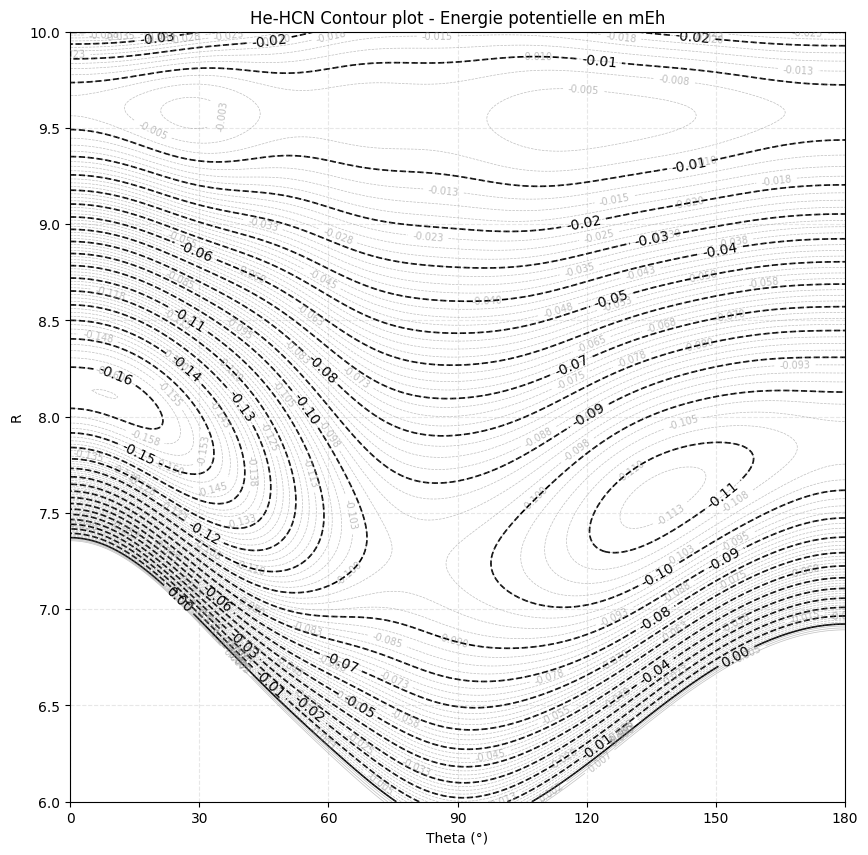

In [95]:
# Definition des axes
theta_grid = np.linspace(0, 180, 250)
r_grid = np.linspace(6, 10, 250)
Theta_mesh, R_mesh = np.meshgrid(theta_grid, r_grid)

# Calcul de la matrice d'energie Z et conversion de uEh en mEh
Z = np.array([
    V_opt(params_opt_cf_sigma, np.full_like(theta_grid, r), theta_grid)
    for r in r_grid
]) / 1000.0

# Masquage des contours en dessous de R=7.2 pour Theta proche de 0
mask_repulsion = (R_mesh < 7.2) & (Theta_mesh < 10)
Z_masked = Z.copy()
Z_masked[mask_repulsion] = np.nan

# Niveaux contours principaux
levels_main = np.arange(-0.2, 0.001, 0.01)

# Niveaux contours secondaires
levels_fine = np.arange(-1, 0.01, 0.0025)


plt.figure(figsize=(10, 10))

# Contours principaux en noir
cp_main = plt.contour(Theta_mesh, R_mesh, Z_masked, levels=levels_main, colors='black', linewidths=1.2)
plt.clabel(cp_main, inline=True, fontsize=10, fmt='%.2f')

# Ajout de lignes de fond plus fines pour la structure
cp_fine = plt.contour(Theta_mesh, R_mesh, Z_masked, levels=levels_fine, colors='gray', alpha=0.5, linewidths=0.5)
plt.clabel(cp_fine, inline=True, fontsize=7, fmt='%.3f')

plt.title("He-HCN Contour plot - Energie potentielle en mEh")
plt.xlabel("Theta (°)")
plt.ylabel("R")

# Ajout de ticks pour l'axe R
plt.yticks(np.arange(6, 10.5, 0.5))
plt.xticks(np.arange(0, 181, 30))

plt.grid(True, linestyle='--', alpha=0.3)

## Ne-HCN

In [47]:
R_Ne = np.asarray(Ne["R"], dtype=float)
Theta_Ne = np.asarray(Ne["Theta"], dtype=float)
V_table_Ne = np.asarray(Ne["Energy"], dtype=float)
R_Ne.shape, Theta_Ne.shape, V_table_Ne.shape

((151,), (151,), (151,))

In [48]:
params_init_cf=np.random.rand(40)
params_opt_cf_Ne, params_cov_Ne = curve_fit(V_curvefit, (R_Ne,Theta_Ne), V_table_Ne, p0=params_init_cf, maxfev=1000000)

In [49]:
b  = params_opt_cf_Ne[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf_Ne[6:10]  # c0, c1, c2, c3
d  = params_opt_cf_Ne[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf_Ne[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf_Ne[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf_Ne[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf_Ne[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")


[b0,b1,b2,b3,b4,b5]       = [1.6751848022395022, 0.4986364056760907, 0.3067753235275076, -0.14140888236235216, -0.1412389328559977, -0.033933843467507954]
[c0,c1,c2,c3]             = [-35615292.95089691, -103339079.01308347, -17502299.198776953, -61850349.31976775]
[d0,d1,d2,d3,d4,d5]       = [9.676383433472116, 4.3287959559317475, 2.803150106532009, -0.4952644028388975, -0.637154246028531, -0.1625058935110022]
[g00,g01,g02,g03,g04,g05] = [29422.700653927925, -45870.88952729468, 30617.187515407993, -168.42258028468103, 454.17706717860403, -8884.70410433579]
[g10,g11,g12,g13,g14,g15] = [-9825.205670349249, 13608.62734078702, -10466.14927261689, -1342.1190118907327, 703.0480596659933, 4394.38605953953]
[g20,g21,g22,g23,g24,g25] = [1217.537749212956, -1297.7492804935675, 1362.075973910643, 235.35839728332692, -175.3722408857123, -721.0420854344965]
[g30,g31,g32,g33,g34,g35] = [-58.4512807666907, 42.34090255582942, -67.67619853763146, -7.06418027782108, 9.623418018212995, 38.73574805714821

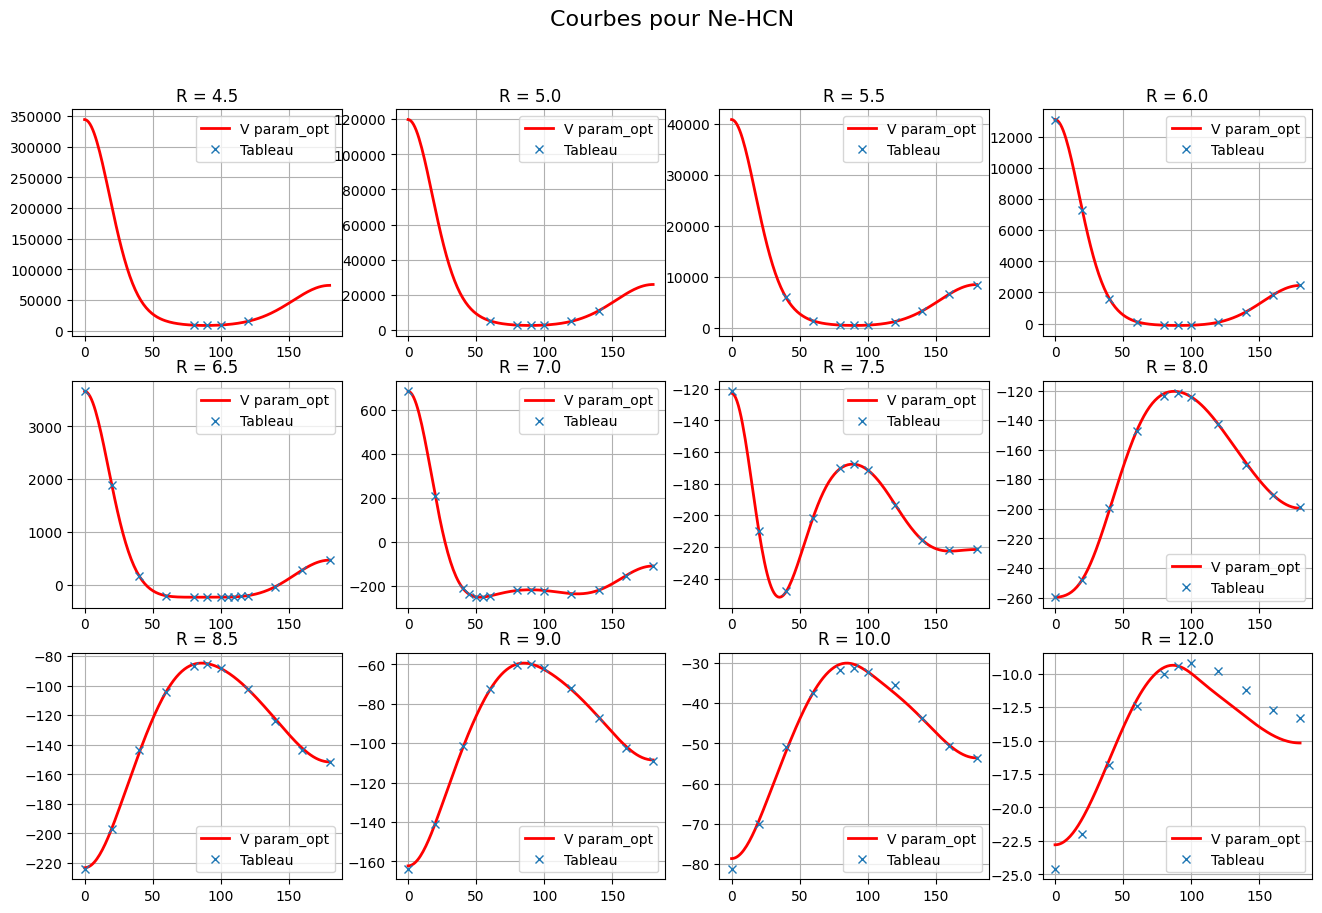

In [50]:
R_vals_Ne = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Courbes pour Ne-HCN', fontsize=16) # Add a general title
axes = axes.ravel()

for ax, r in zip(axes, R_vals_Ne):

    # Prediction : V_opt
    Z_pred_total = V_opt(params_opt_cf_Ne, np.full_like(x, r), x)

    # Données de l'article
    mask = np.isclose(Ne["R"], r)
    Theta_sel = Ne["Theta"][mask]
    Energy_sel = Ne["Energy"][mask]

    order = np.argsort(Theta_sel)

    ax.plot(x, Z_pred_total, color="red", linewidth=2, label="V param_opt")
    ax.plot(Theta_sel[order], Energy_sel[order], 'x', label="Tableau")

    ax.set_title(f"R = {r}")
    ax.grid()
    ax.legend()

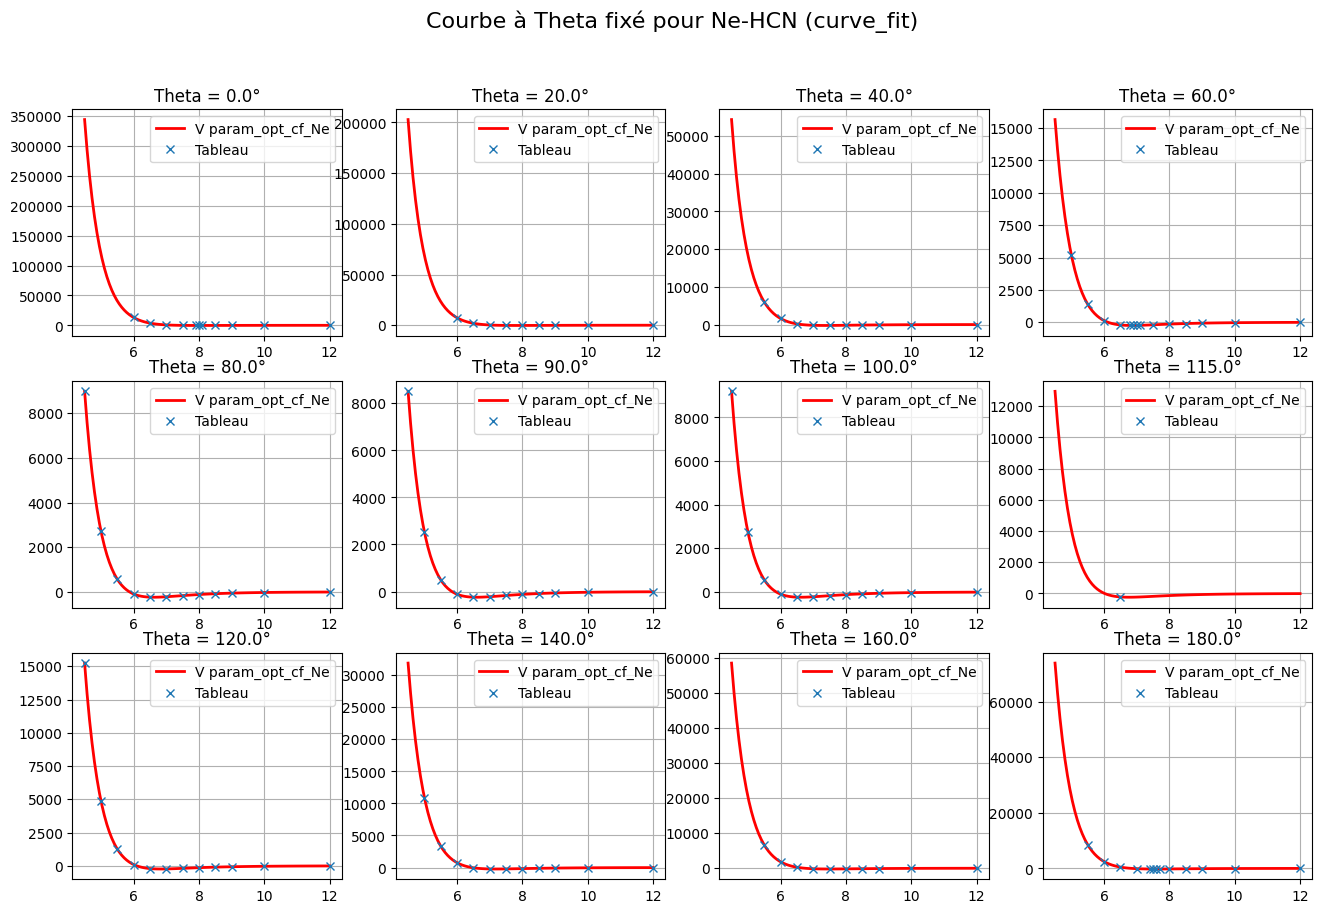

In [51]:
Theta_vals_Ne = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])

x_R_Ne = np.linspace(4.5, 12, 100)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Courbe à Theta fixé pour Ne-HCN (curve_fit)', fontsize=16)
axes = axes.ravel()

for ax, th in zip(axes, Theta_vals_Ne):
    # Prediction : V_opt
    Z_pred_total = V_opt(params_opt_cf_Ne, x_R_Ne, np.full_like(x_R_Ne, th))

    # Données de l'article
    mask = np.isclose(Ne["Theta"], th)
    R_sel = Ne["R"][mask]
    Energy_sel = Ne["Energy"][mask]

    order = np.argsort(R_sel)

    ax.plot(x_R_Ne, Z_pred_total, color="red", linewidth=2, label="V param_opt_cf_Ne")
    ax.plot(R_sel[order], Energy_sel[order], 'x', label="Tableau")

    ax.set_title(f"Theta = {th}°")
    ax.grid()
    ax.legend()

## Ar-HCN

In [52]:
R_Ar = np.asarray(Ar["R"], dtype=float)
Theta_Ar = np.asarray(Ar["Theta"], dtype=float)
V_table_Ar = np.asarray(Ar["Energy"], dtype=float)
R_Ar.shape, Theta_Ar.shape, V_table_Ar.shape

((140,), (140,), (140,))

In [53]:
params_init_cf= 2*np.random.rand(40)-1
params_opt_cf_Ar, params_cov_Ar, output1, output2, output3 = curve_fit(V_curvefit, (R_Ar,Theta_Ar), V_table_Ar, p0=params_init_cf, maxfev=100000, sigma=V_table_Ar, full_output=True)

/tmp/ipykernel_3426/2755791350.py:33: RuntimeWarning:

overflow encountered in exp



In [54]:
params_cov_Ar

array([[ 3.38487668e-04,  1.80254099e-04, -3.29728037e-04, ...,
         7.82525712e-02, -2.46205401e-02, -7.74277004e-03],
       [ 1.80254099e-04,  3.10930580e-04, -1.46330684e-04, ...,
         3.01642426e-02, -9.55636248e-03, -2.93725595e-03],
       [-3.29728037e-04, -1.46330684e-04,  4.54112882e-04, ...,
        -4.34681753e-02,  1.34123345e-02,  4.21738802e-03],
       ...,
       [ 7.82525712e-02,  3.01642426e-02, -4.34681753e-02, ...,
         5.28903154e+03, -1.67593745e+03, -5.27540150e+02],
       [-2.46205401e-02, -9.55636248e-03,  1.34123345e-02, ...,
        -1.67593745e+03,  5.31056771e+02,  1.67162553e+02],
       [-7.74277004e-03, -2.93725595e-03,  4.21738802e-03, ...,
        -5.27540150e+02,  1.67162553e+02,  5.26186450e+01]])

In [55]:
params_init_cf

array([ 0.95556992, -0.75333976,  0.97223641,  0.55670804, -0.90532991,
        0.89126563, -0.04713349, -0.4357123 , -0.40251684, -0.91021795,
       -0.00713337, -0.68138907,  0.91272426,  0.29637197, -0.94717376,
        0.76447678, -0.22055188, -0.70123399,  0.70797781,  0.73222178,
        0.82088679, -0.8750789 , -0.95393881, -0.26440407,  0.99270298,
        0.1961388 ,  0.4620367 , -0.4638004 , -0.66256305,  0.12160982,
       -0.66585568,  0.68714579, -0.79932066, -0.07811057, -0.43150318,
       -0.72505514, -0.57918611, -0.40830623,  0.65020343,  0.28793031])

In [56]:
b  = params_opt_cf_Ar[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf_Ar[6:10]  # c0, c1, c2, c3
d  = params_opt_cf_Ar[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf_Ar[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf_Ar[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf_Ar[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf_Ar[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [1.2311250643870126, 0.018679579067568383, -0.09840770252051988, 0.017068341011646514, 0.036682280481660084, 0.013600941208335922]
[c0,c1,c2,c3]             = [-118420334.74960269, -398664411.42143524, -26309536.740618356, -172823235.8487412]
[d0,d1,d2,d3,d4,d5]       = [12.927736211144058, 0.9623066829945031, 0.03113590394021747, 0.24564181335370858, 0.3232166068628947, 0.11173946659103934]
[g00,g01,g02,g03,g04,g05] = [332.3093112958124, -301.81988967874497, 450.34025577553956, -89.76997789690402, 66.64766543909533, -4.095610741159669]
[g10,g11,g12,g13,g14,g15] = [-96.80771687774516, 99.53597985412156, -141.27854832617874, 28.124111314181665, -17.389220315831018, 0.434173173876856]
[g20,g21,g22,g23,g24,g25] = [9.425465095355328, -11.1274882543788, 15.029764716609169, -2.877228604674222, 1.4145361158128198, 0.07904181466855736]
[g30,g31,g32,g33,g34,g35] = [-0.32486826320777135, 0.43828013019199324, -0.5551930084610271, 0.09719961643618774, -0.030793834215466

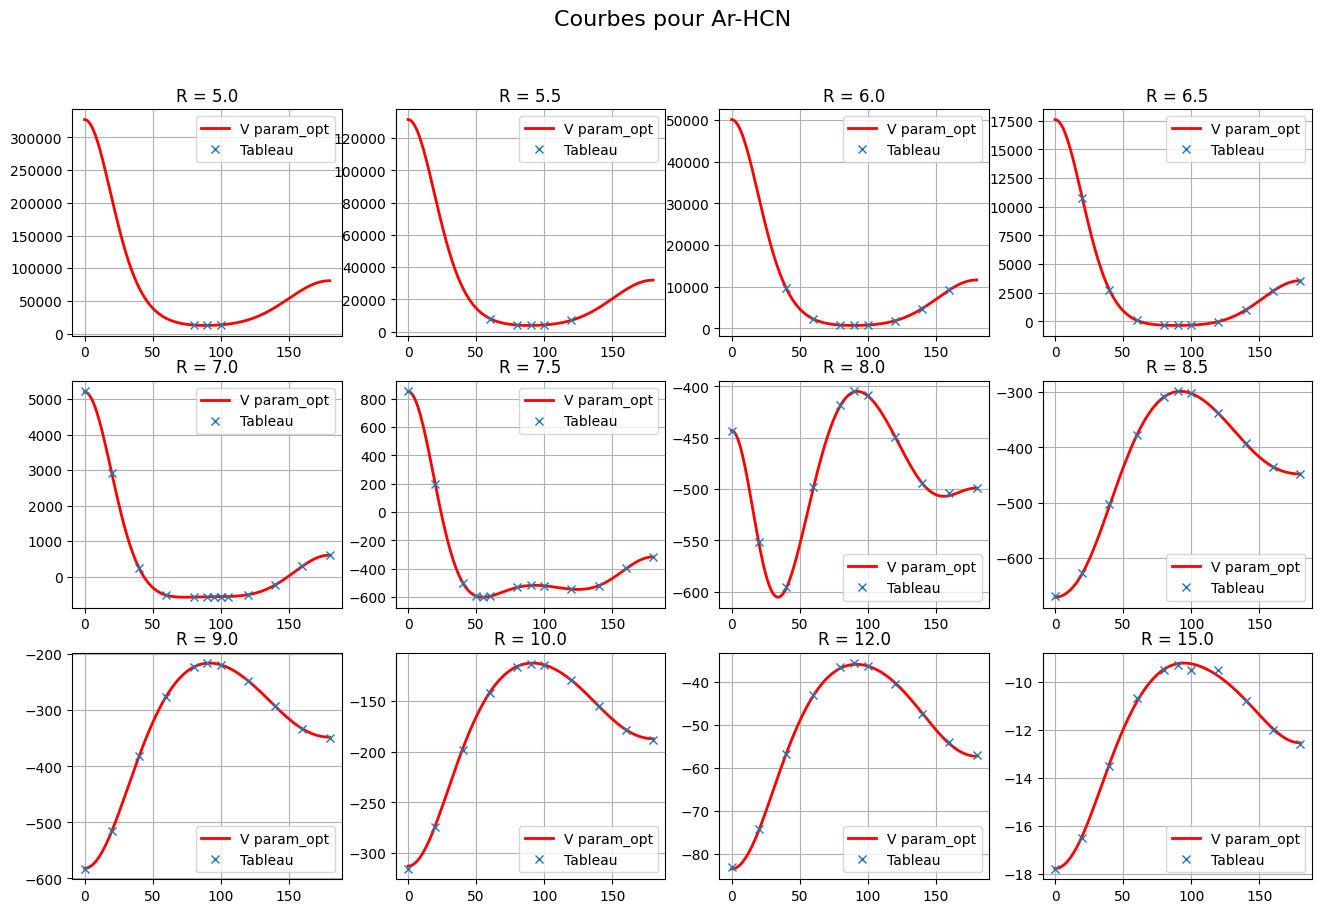

In [57]:
R_vals_Ar = np.array([5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0,15.0])
x = np.linspace(0, 180, 180)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Courbes pour Ar-HCN', fontsize=16)
axes = axes.ravel()

for ax, r in zip(axes, R_vals_Ar):

    # Prediction : V_opt
    Z_pred_total = V_opt(params_opt_cf_Ar, np.full_like(x, r), x)

    # Données de l'article
    mask = np.isclose(Ar["R"], r)
    Theta_sel = Ar["Theta"][mask]
    Energy_sel = Ar["Energy"][mask]

    order = np.argsort(Theta_sel)

    ax.plot(x, Z_pred_total, color="red", linewidth=2, label="V param_opt")
    ax.plot(Theta_sel[order], Energy_sel[order], 'x', label="Tableau")

    ax.set_title(f"R = {r}")
    ax.grid()
    ax.legend()

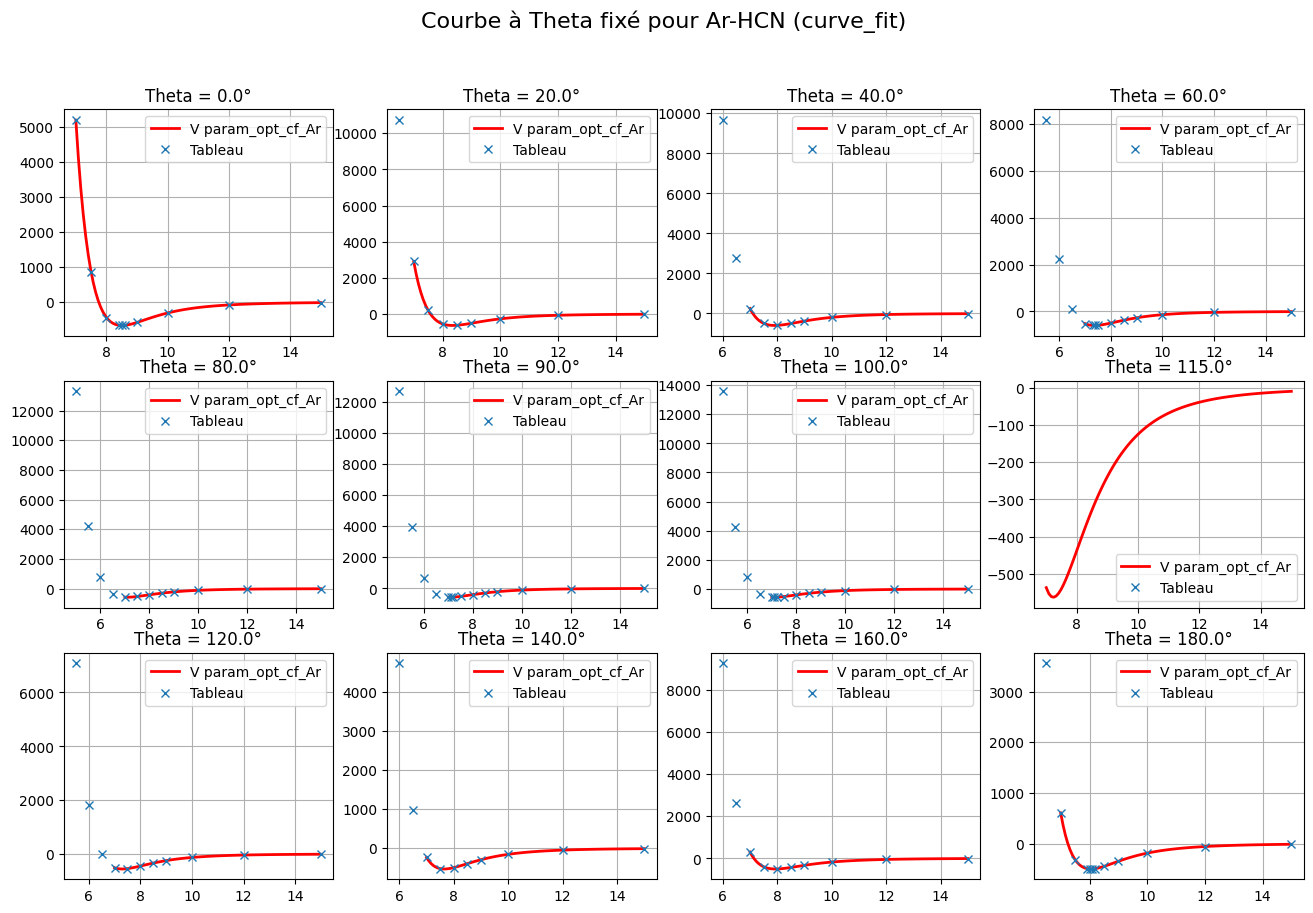

In [58]:
Theta_vals_Ar = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])

x_R_Ar = np.linspace(7, 15, 100)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Courbe à Theta fixé pour Ar-HCN (curve_fit)', fontsize=16)
axes = axes.ravel()

for ax, th in zip(axes, Theta_vals_Ar):
    # Prediction : V_opt
    Z_pred_total = V_opt(params_opt_cf_Ar, x_R_Ar, np.full_like(x_R_Ar, th))

    # Données de l'article
    mask = np.isclose(Ar["Theta"], th)
    R_sel = Ar["R"][mask]
    Energy_sel = Ar["Energy"][mask]

    order = np.argsort(R_sel)

    ax.plot(x_R_Ar, Z_pred_total, color="red", linewidth=2, label="V param_opt_cf_Ar")
    ax.plot(R_sel[order], Energy_sel[order], 'x', label="Tableau")

    ax.set_title(f"Theta = {th}°")
    ax.grid()
    ax.legend()

## Kr-HCN

In [59]:
R_Kr = np.asarray(Kr["R"], dtype=float)
Theta_Kr = np.asarray(Kr["Theta"], dtype=float)
V_table_Kr = np.asarray(Kr["Energy"], dtype=float)
R_Kr.shape, Theta_Kr.shape, V_table_Kr.shape

((133,), (133,), (133,))

In [60]:
params_init_cf=np.random.rand(40)
params_opt_cf_Kr, params_cov_Kr = curve_fit(V_curvefit, (R_Kr,Theta_Kr), V_table_Kr, p0=params_init_cf, maxfev=1000000)

/tmp/ipykernel_3426/2755791350.py:33: RuntimeWarning:

overflow encountered in exp



In [61]:
b  = params_opt_cf_Kr[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf_Kr[6:10]  # c0, c1, c2, c3
d  = params_opt_cf_Kr[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf_Kr[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf_Kr[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf_Kr[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf_Kr[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [1.2841549683756988, -0.2984840767525284, 0.06389572899717162, 0.0960565591625227, 0.018141760281712254, -0.012097733511949819]
[c0,c1,c2,c3]             = [-180353815.18409166, 170.59452404814937, -56863001.52313406, -8295.214392973134]
[d0,d1,d2,d3,d4,d5]       = [10.364128160517518, -1.3435760228270932, 1.0354101889934852, 0.608895977799727, 0.21112643741601603, -0.039236611884573926]
[g00,g01,g02,g03,g04,g05] = [4481.295109937019, 7542.407670172881, 3477.939166251665, 1452.026592793145, 1346.1998788172775, 316.1766074704471]
[g10,g11,g12,g13,g14,g15] = [-963.821566530252, -2623.857352583328, -839.012143409987, -231.07337156726464, -403.6907264746648, -86.534246750127]
[g20,g21,g22,g23,g24,g25] = [64.92626155743899, 279.7862996228416, 85.40457208108512, -4.238275230615728, 43.72178451423179, 8.4603144993659]
[g30,g31,g32,g33,g34,g35] = [-1.7745043782487713, -8.990989647759484, -3.9694344216875894, 1.2832298045568986, -1.6703677525697442, -0.30961141383390

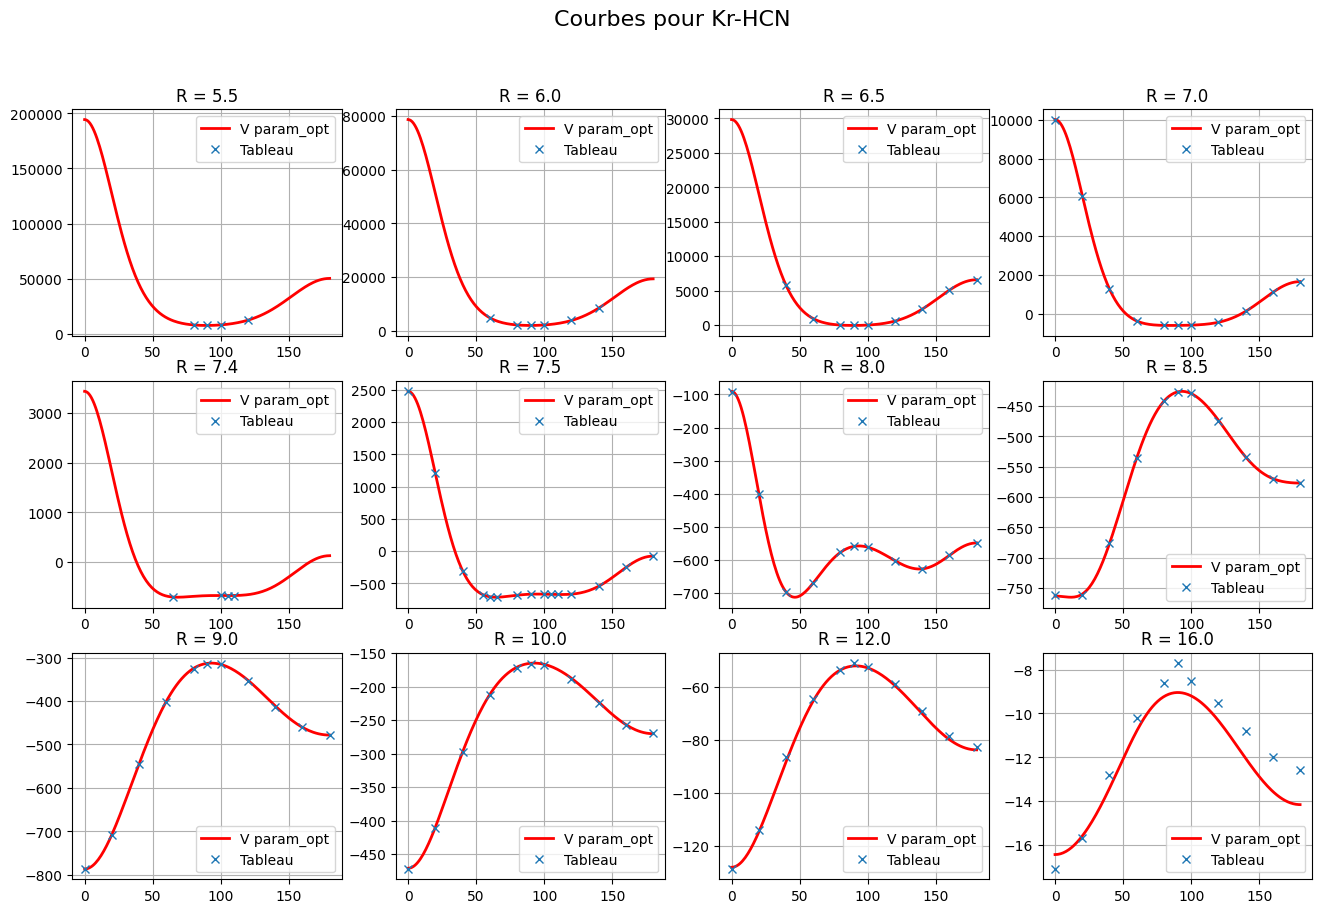

In [62]:
R_vals_Kr = np.array([5.5,6.0,6.5,7.0,7.4,7.5,8.0,8.5,9.0,10.0,12.0,16.0])
x = np.linspace(0, 180, 180)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Courbes pour Kr-HCN', fontsize=16)
axes = axes.ravel()

for ax, r in zip(axes, R_vals_Kr):

    # Prediction : V_opt
    Z_pred_total = V_opt(params_opt_cf_Kr, np.full_like(x, r), x)

    # Données de l'article
    mask = np.isclose(Kr["R"], r)
    Theta_sel = Kr["Theta"][mask]
    Energy_sel = Kr["Energy"][mask]

    order = np.argsort(Theta_sel)

    ax.plot(x, Z_pred_total, color="red", linewidth=2, label="V param_opt")
    ax.plot(Theta_sel[order], Energy_sel[order], 'x', label="Tableau")

    ax.set_title(f"R = {r}")
    ax.grid()
    ax.legend()

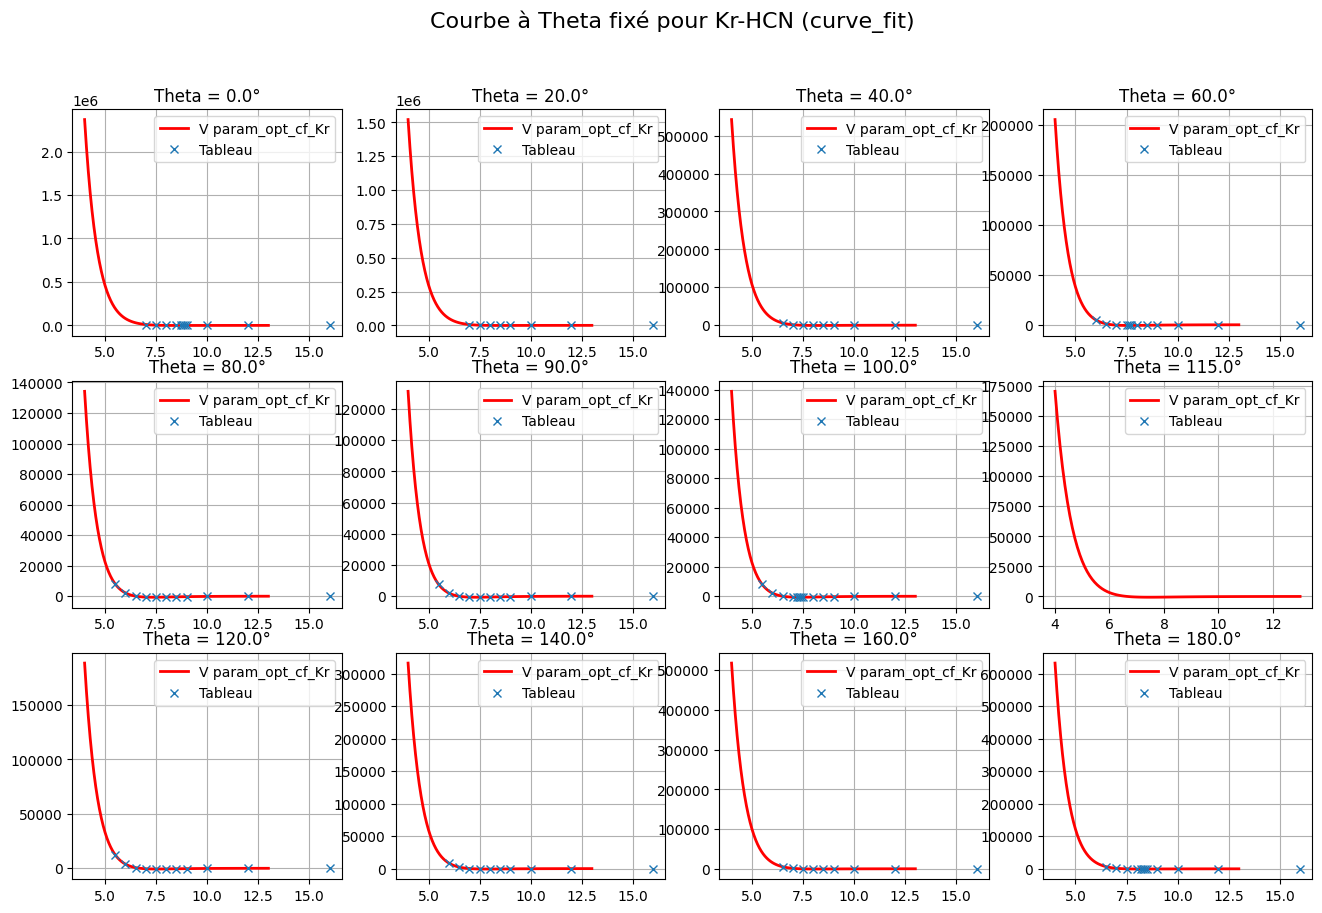

In [63]:
Theta_vals_Kr = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])

x_R_Kr = np.linspace(4, 13, 100)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Courbe à Theta fixé pour Kr-HCN (curve_fit)', fontsize=16)
axes = axes.ravel()

for ax, th in zip(axes, Theta_vals_Kr):
    # Prediction : V_opt
    Z_pred_total = V_opt(params_opt_cf_Kr, x_R_Kr, np.full_like(x_R_Kr, th))

    # Données de l'article
    mask = np.isclose(Kr["Theta"], th)
    R_sel = Kr["R"][mask]
    Energy_sel = Kr["Energy"][mask]

    order = np.argsort(R_sel)

    ax.plot(x_R_Kr, Z_pred_total, color="red", linewidth=2, label="V param_opt_cf_Kr")
    ax.plot(R_sel[order], Energy_sel[order], 'x', label="Tableau")

    ax.set_title(f"Theta = {th}°")
    ax.grid()
    ax.legend()

# Méthode 2 : least_squares

## Calculs

In [64]:
def residus_He(params):
    # params est un array de 40 valeurs
    V_pred = V_opt(params, He["R"], He["Theta"])
    # .ravel() force le résultat en un tableau 1D pour least_squares
    return (V_pred - He["Energy"]).ravel()

In [65]:
# Valeurs initiales des paramètres
p0 = params_init_cf

# La fonction residus_He renvoie maintenant un tableau 1D
result = least_squares(residus_He, p0)
params_opt_ls = result.x  # tes 40 paramètres optimaux

In [66]:
params_opt_cf, params_opt_ls

(array([-2.77803697e-01,  2.75570097e-01,  4.22014964e+00,  3.47276916e+00,
         1.07361190e+00,  2.02557405e+00,  6.56406945e+07,  9.28338645e+07,
         5.92467897e+07,  1.22220613e+08,  6.26435003e-01,  8.28311717e-01,
         4.86868051e+00, -2.96577076e+00,  2.60044436e+00, -3.64021995e+00,
         1.56446764e+02,  2.07370660e+02,  4.54438261e+02,  3.83031171e+02,
         1.88696028e+02,  2.09178939e+02, -6.15308559e-03, -1.65957165e-01,
        -1.19200650e-01, -8.35376891e-02, -1.33653942e-01, -9.42342417e-03,
        -3.89910402e+00, -5.13953272e+00, -1.13074550e+01, -9.53376864e+00,
        -4.67985697e+00, -5.21312383e+00,  7.53966089e-02,  9.91963875e-02,
         2.18531277e-01,  1.84272718e-01,  9.03450818e-02,  1.00804175e-01]),
 array([ 1.91696872e+00, -8.23316689e-01,  6.97824578e-03, -4.77487982e-02,
        -1.73835603e-01,  5.78004561e-01,  1.60411750e-01,  6.77397501e-01,
         1.96977034e-01,  3.47232171e-01,  1.93958048e+01, -3.54365217e+00,
         1

## Affichage

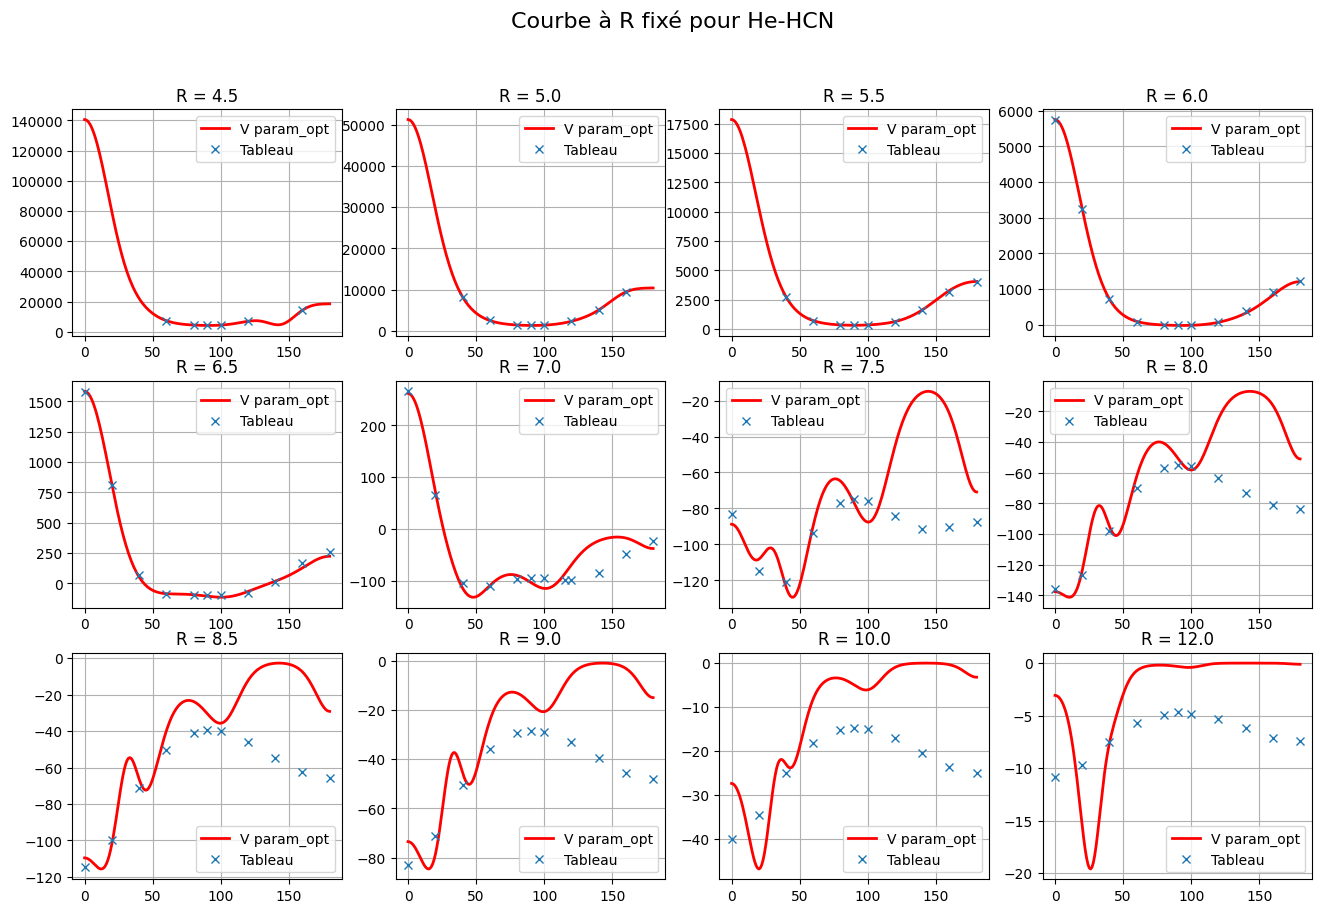

In [67]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Courbe à R fixé pour He-HCN', fontsize=16)
axes = axes.ravel()

for ax, r in zip(axes, R_vals):

    # Prediction : V_opt
    Z_pred_total = V_opt(params_opt_ls, np.full_like(x, r), x)

    # Données de l'article
    mask = np.isclose(He["R"], r)
    Theta_sel = He["Theta"][mask]
    Energy_sel = He["Energy"][mask]

    order = np.argsort(Theta_sel)

    ax.plot(x, Z_pred_total, color="red", linewidth=2, label="V param_opt")
    ax.plot(Theta_sel[order], Energy_sel[order], 'x', label="Tableau")

    ax.set_title(f"R = {r}")
    ax.grid()
    ax.legend()

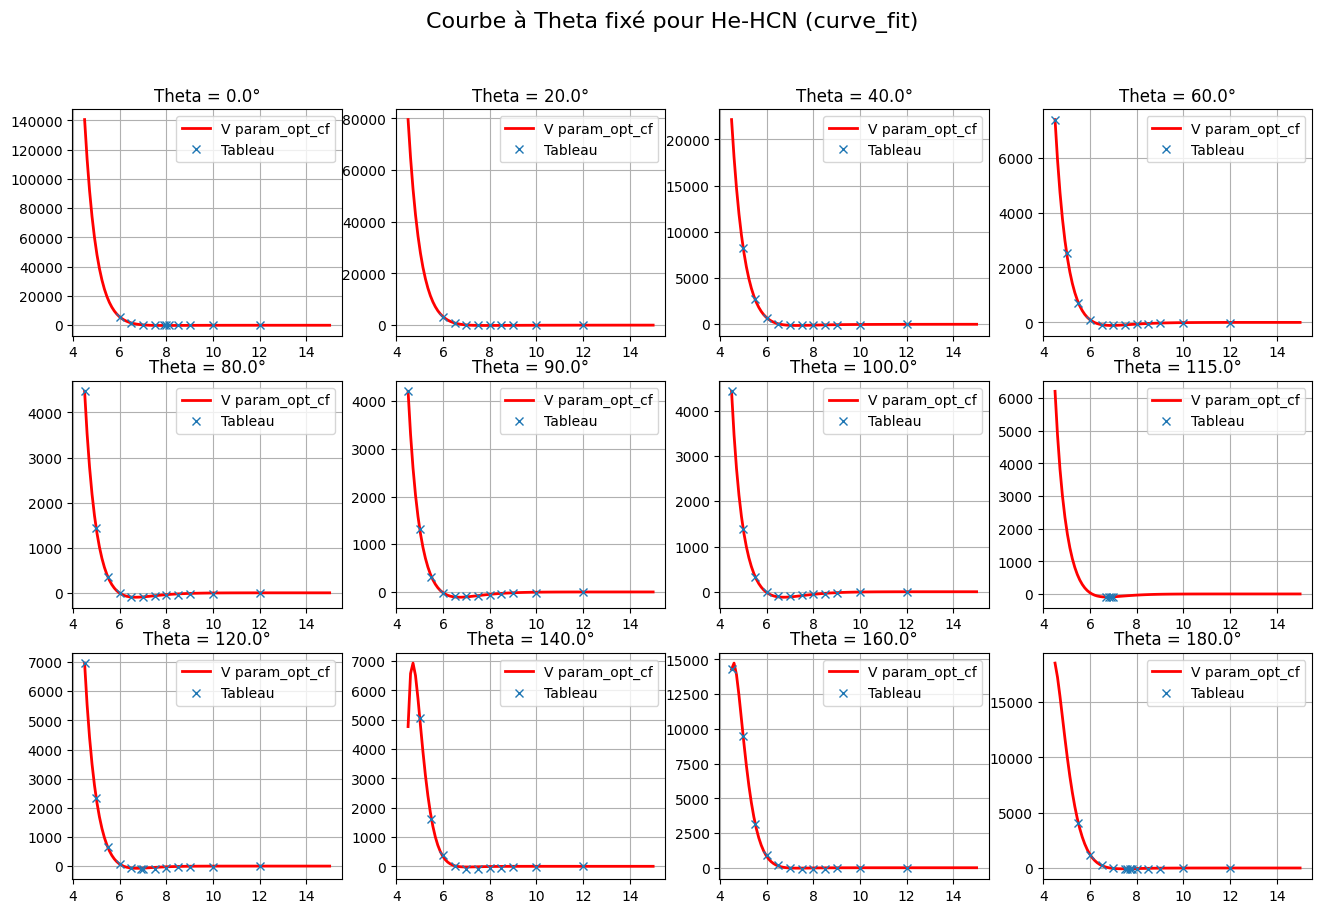

In [68]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])

x_R = np.linspace(4.5, 15, 100)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Courbe à Theta fixé pour He-HCN (curve_fit)', fontsize=16)
axes = axes.ravel()

for ax, th in zip(axes, Theta_vals):
    # Prediction : V_opt
    Z_pred_total = V_opt(params_opt_ls, x_R, np.full_like(x_R, th))

    # Données de l'article
    mask = np.isclose(He["Theta"], th)
    R_sel = He["R"][mask]
    Energy_sel = He["Energy"][mask]

    order = np.argsort(R_sel)

    ax.plot(x_R, Z_pred_total, color="red", linewidth=2, label="V param_opt_cf")
    ax.plot(R_sel[order], Energy_sel[order], 'x', label="Tableau")

    ax.set_title(f"Theta = {th}°")
    ax.grid()
    ax.legend()

# Méthode 3 : differential_evolution

In [69]:
def objective(params):
    # Utilisation des points de données 1D pour correspondre à He["Energy"]
    V_pred = V_opt(params, He["R"], He["Theta"])
    return np.sum((V_pred - He["Energy"]) ** 2)

In [70]:
# 40 paramètres
intervalles = [(-10000000, 10000000)] * 40

# Run differential_evolution
result_de = differential_evolution(objective, intervalles, seed=40, maxiter=10000)
params_opt_de = result_de.x

/tmp/ipykernel_3426/2755791350.py:33: RuntimeWarning:

overflow encountered in exp

/tmp/ipykernel_3426/2088027305.py:4: RuntimeWarning:

overflow encountered in square



In [71]:
b_de  = params_opt_de[0:6]   # b0, b1, b2, b3, b4, b5
c_de  = params_opt_de[6:10]  # c0, c1, c2, c3
d_de  = params_opt_de[10:16] # d0, d1, d2, d3, d4, d5
g0_de = params_opt_de[16:22] # g00, g01, g02, g03, g04, g05
g1_de = params_opt_de[22:28] # g10, g11, g12, g13, g14, g15
g2_de = params_opt_de[28:34] # g20, g21, g22, g23, g24, g25
g3_de = params_opt_de[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b_de[0]}, {b_de[1]}, {b_de[2]}, {b_de[3]}, {b_de[4]}, {b_de[5]}]")
print(f"[c0,c1,c2,c3]             = [{c_de[0]}, {c_de[1]}, {c_de[2]}, {c_de[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d_de[0]}, {d_de[1]}, {d_de[2]}, {d_de[3]}, {d_de[4]}, {d_de[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0_de[0]}, {g0_de[1]}, {g0_de[2]}, {g0_de[3]}, {g0_de[4]}, {g0_de[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1_de[0]}, {g1_de[1]}, {g1_de[2]}, {g1_de[3]}, {g1_de[4]}, {g1_de[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2_de[0]}, {g2_de[1]}, {g2_de[2]}, {g2_de[3]}, {g2_de[4]}, {g2_de[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3_de[0]}, {g3_de[1]}, {g3_de[2]}, {g3_de[3]}, {g3_de[4]}, {g3_de[5]}]")

[b0,b1,b2,b3,b4,b5]       = [8243174.463749632, 3670817.907683002, 5640641.62674486, -7588052.479335037, 1274556.4320045412, -1219309.1446542193]
[c0,c1,c2,c3]             = [10000000.0, -9173481.428186541, 9950700.364829825, -9664079.81595527]
[d0,d1,d2,d3,d4,d5]       = [-2602075.9127463577, 6430008.8411607435, 6455711.094666035, -9024741.401860457, -4948365.187413368, 5566819.569543254]
[g00,g01,g02,g03,g04,g05] = [1035228.9463942377, 3424359.334730329, -6649494.790091814, -1549517.3309909815, 6097124.062262276, -5686088.390638413]
[g10,g11,g12,g13,g14,g15] = [-8434356.666679734, -3894158.658450182, -1135098.6531164376, 941201.1996168279, 493898.2886965038, 713244.4203000676]
[g20,g21,g22,g23,g24,g25] = [2785922.8873014688, -4654838.790946357, -4572712.576294509, 1929758.3633900706, 9857503.086221961, -2932804.9528384013]
[g30,g31,g32,g33,g34,g35] = [-2580689.734092736, -9727850.06211917, 9554333.611981511, 6964842.929989557, -6043017.4848466385, 2349077.451807815]


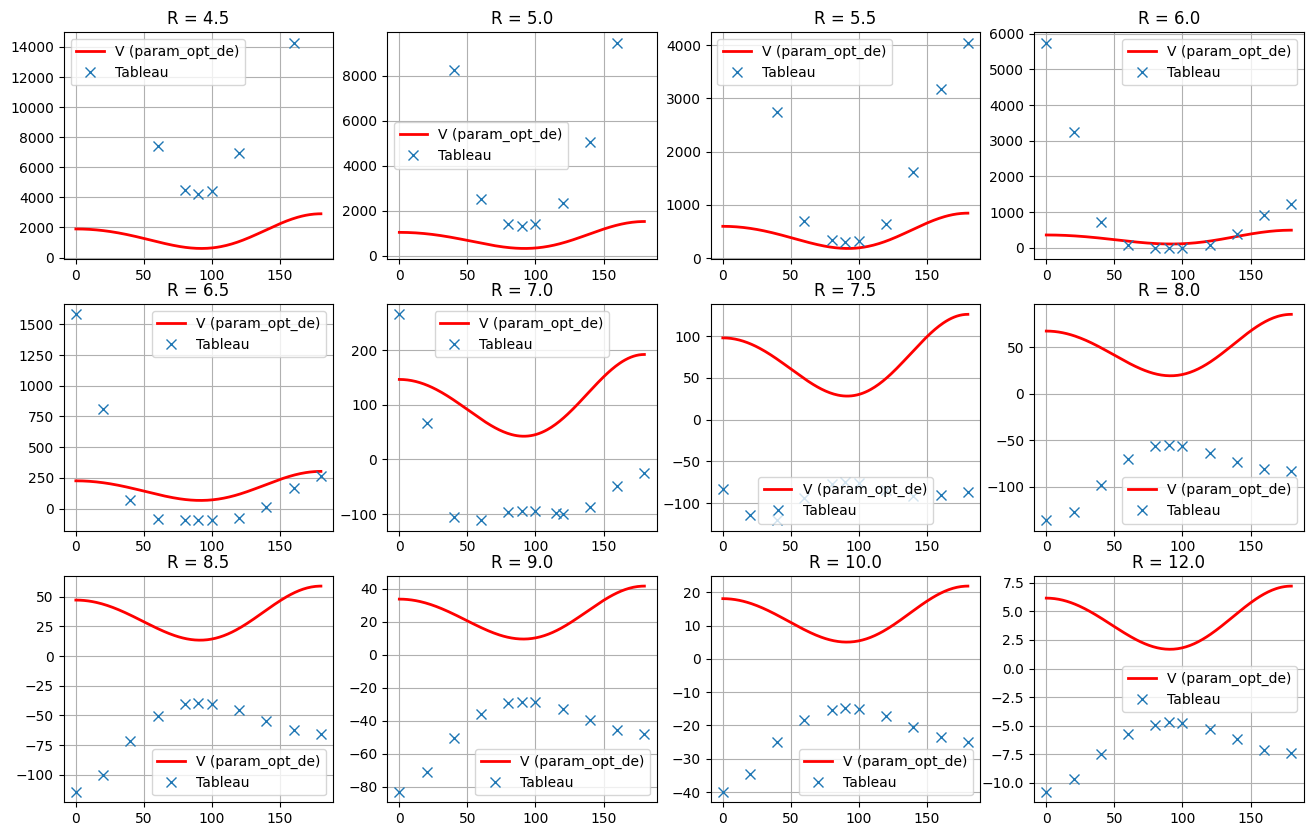

In [72]:
x = np.linspace(0, 180, 180)
# grille 3 lignes × 4 colonnes
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Matrice d'axes -> tableau 1D
axes = axes.ravel()

for ax, r in zip(axes, R_vals):

    # On utilise .squeeze() pour transformer le (1, 180) en (180,)
    Z_pred_de = V_opt(params_opt_de, np.full_like(x, r), x)

    # Valeurs correspondantes du tableau initial
    mask = np.isclose(He["R"], r)
    Theta_sel = He["Theta"][mask]
    Energy_sel = He["Energy"][mask]

    # Remise en ordre des angles
    order = np.argsort(Theta_sel)

    ax.plot(x, Z_pred_de, linewidth=2, label="V (param_opt_de)", color="red")
    ax.plot(Theta_sel[order], Energy_sel[order], 'x', markersize=7, label="Tableau")

    ax.set_title(f"R = {r}")
    ax.grid()
    ax.legend()

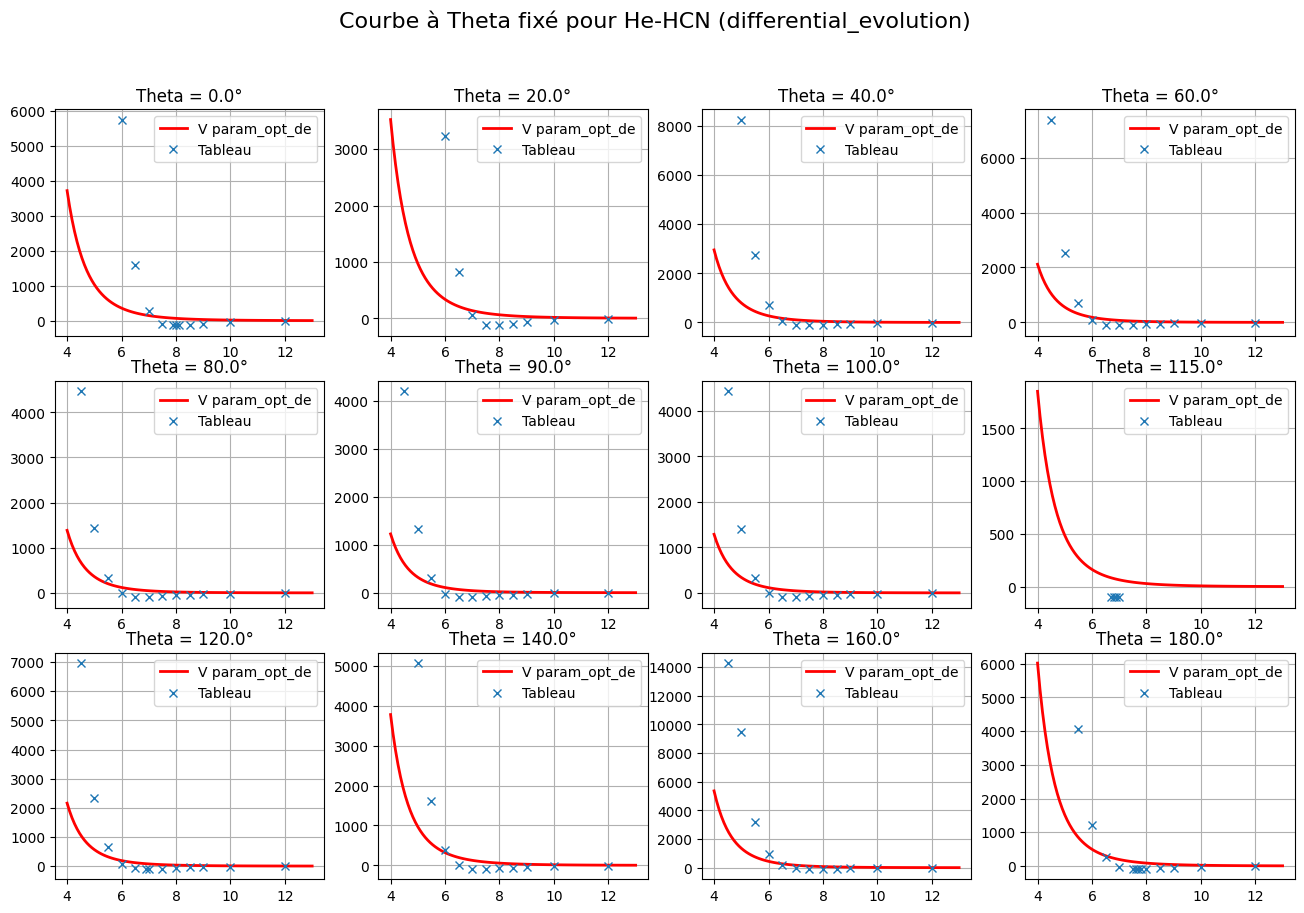

In [73]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])

x_R = np.linspace(4, 13, 100)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Courbe à Theta fixé pour He-HCN (differential_evolution)', fontsize=16)
axes = axes.ravel()

for ax, th in zip(axes, Theta_vals):
    # Prediction : V_opt
    Z_pred_total = V_opt(params_opt_de, x_R, np.full_like(x_R, th))

    # Données de l'article
    mask = np.isclose(He["Theta"], th)
    R_sel = He["R"][mask]
    Energy_sel = He["Energy"][mask]

    order = np.argsort(R_sel)

    ax.plot(x_R, Z_pred_total, color="red", linewidth=2, label="V param_opt_de")
    ax.plot(R_sel[order], Energy_sel[order], 'x', label="Tableau")

    ax.set_title(f"Theta = {th}°")
    ax.grid()
    ax.legend()

## Affinage avec least_squares

In [74]:
result2_ls = least_squares(residus_He, result_de.x)

/tmp/ipykernel_3426/2755791350.py:33: RuntimeWarning:

overflow encountered in exp



In [75]:
params_opt2_ls = result2_ls.x

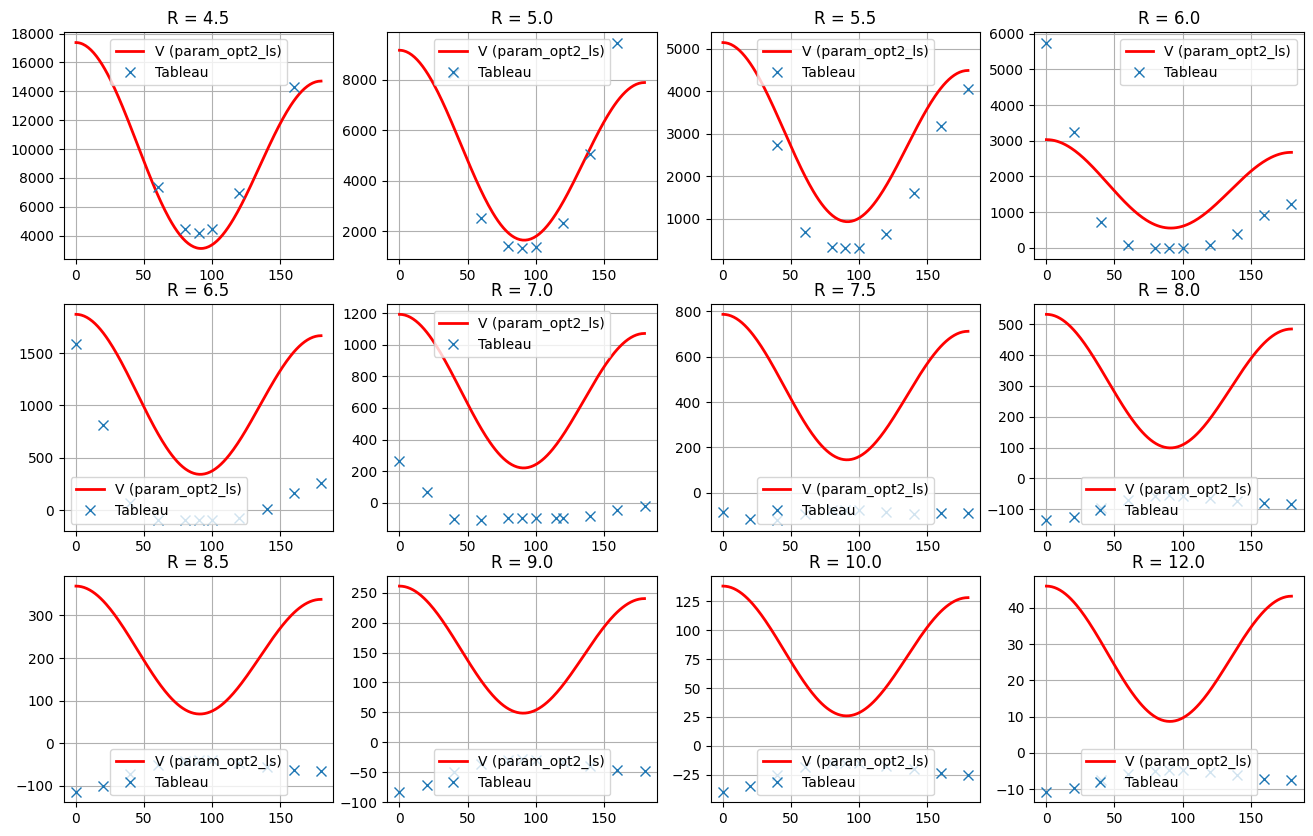

In [76]:
x = np.linspace(0, 180, 180)
# grille 3 lignes × 4 colonnes
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Matrice d'axes -> tableau 1D
axes = axes.ravel()

for ax, r in zip(axes, R_vals):

    # On utilise .squeeze() pour transformer le (1, 180) en (180,)
    Z_pred2_ls = V_opt(params_opt2_ls, np.full_like(x, r), x)

    # Valeurs correspondantes du tableau initial
    mask = np.isclose(He["R"], r)
    Theta_sel = He["Theta"][mask]
    Energy_sel = He["Energy"][mask]

    # Remise en ordre des angles
    order = np.argsort(Theta_sel)

    ax.plot(x, Z_pred2_ls, linewidth=2, label="V (param_opt2_ls)", color="red")
    ax.plot(Theta_sel[order], Energy_sel[order], 'x', markersize=7, label="Tableau")

    ax.set_title(f"R = {r}")
    ax.grid()
    ax.legend()

# Méthode 4 : lmfit